In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("./module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
molecular_descriptors_df_I = pred_model.prepare_data('QSPR_epoxidation_model_III.xlsx')

 31%|█████████████████████████▏                                                        | 19/62 [00:01<00:02, 17.82it/s]

C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaco

100%|██████████████████████████████████████████████████████████████████████████████████| 62/62 [00:01<00:00, 40.88it/s]


Data size (rows, columns): (62, 3874)
Data size after first reduction (rows, columns): (62, 3227)
Data size after second reduction (rows, columns): (62, 1340)


In [3]:
#molecular_descriptors_df_II = pred_model.prepare_data('QSPR_epoxidation_model_II.xlsx')

Data size after first reduction (rows, columns): (62, 1342)


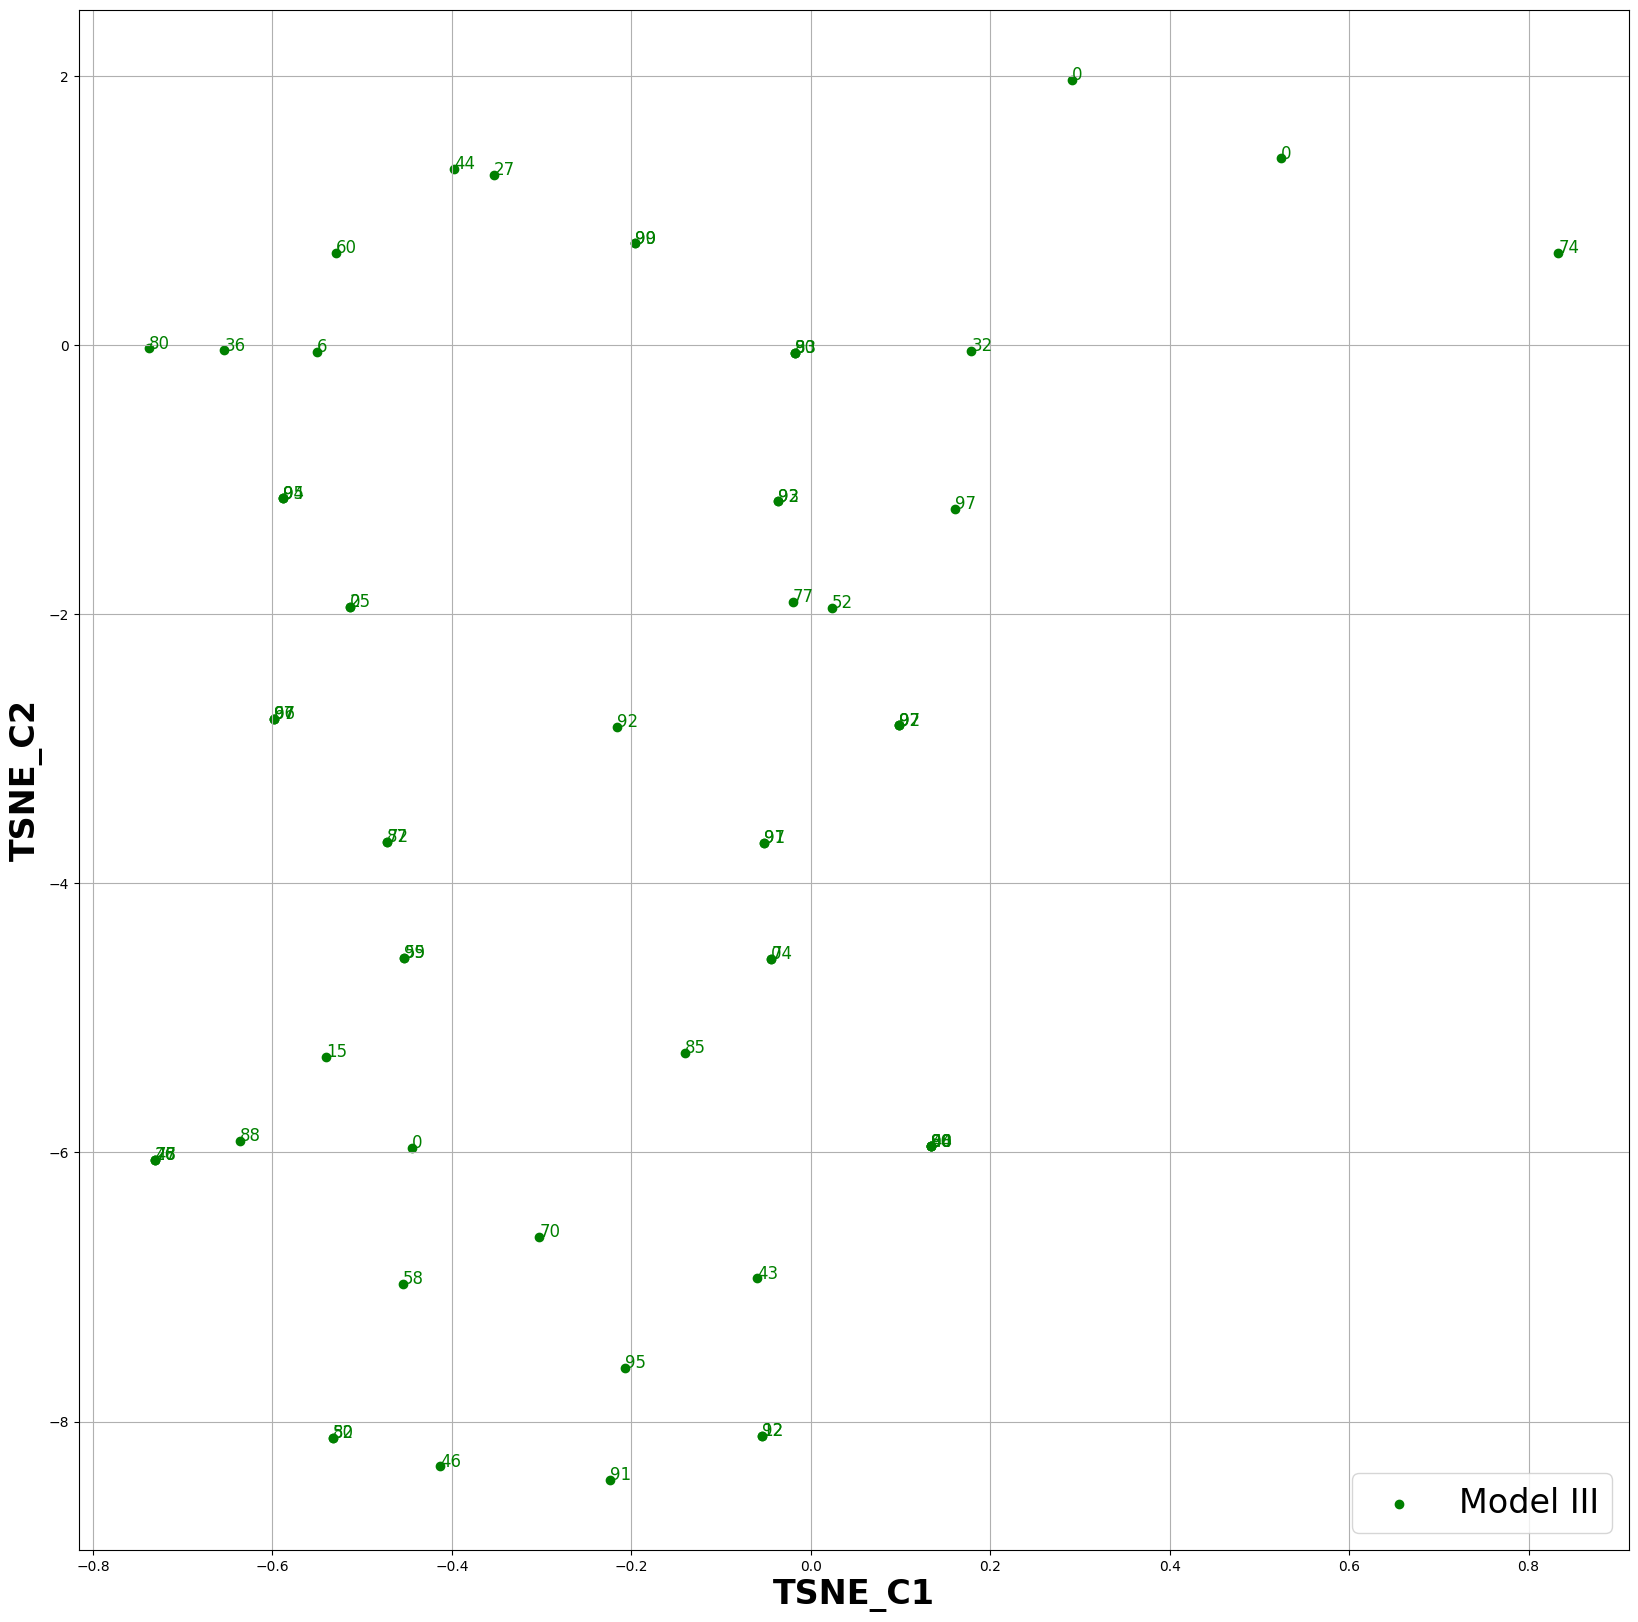

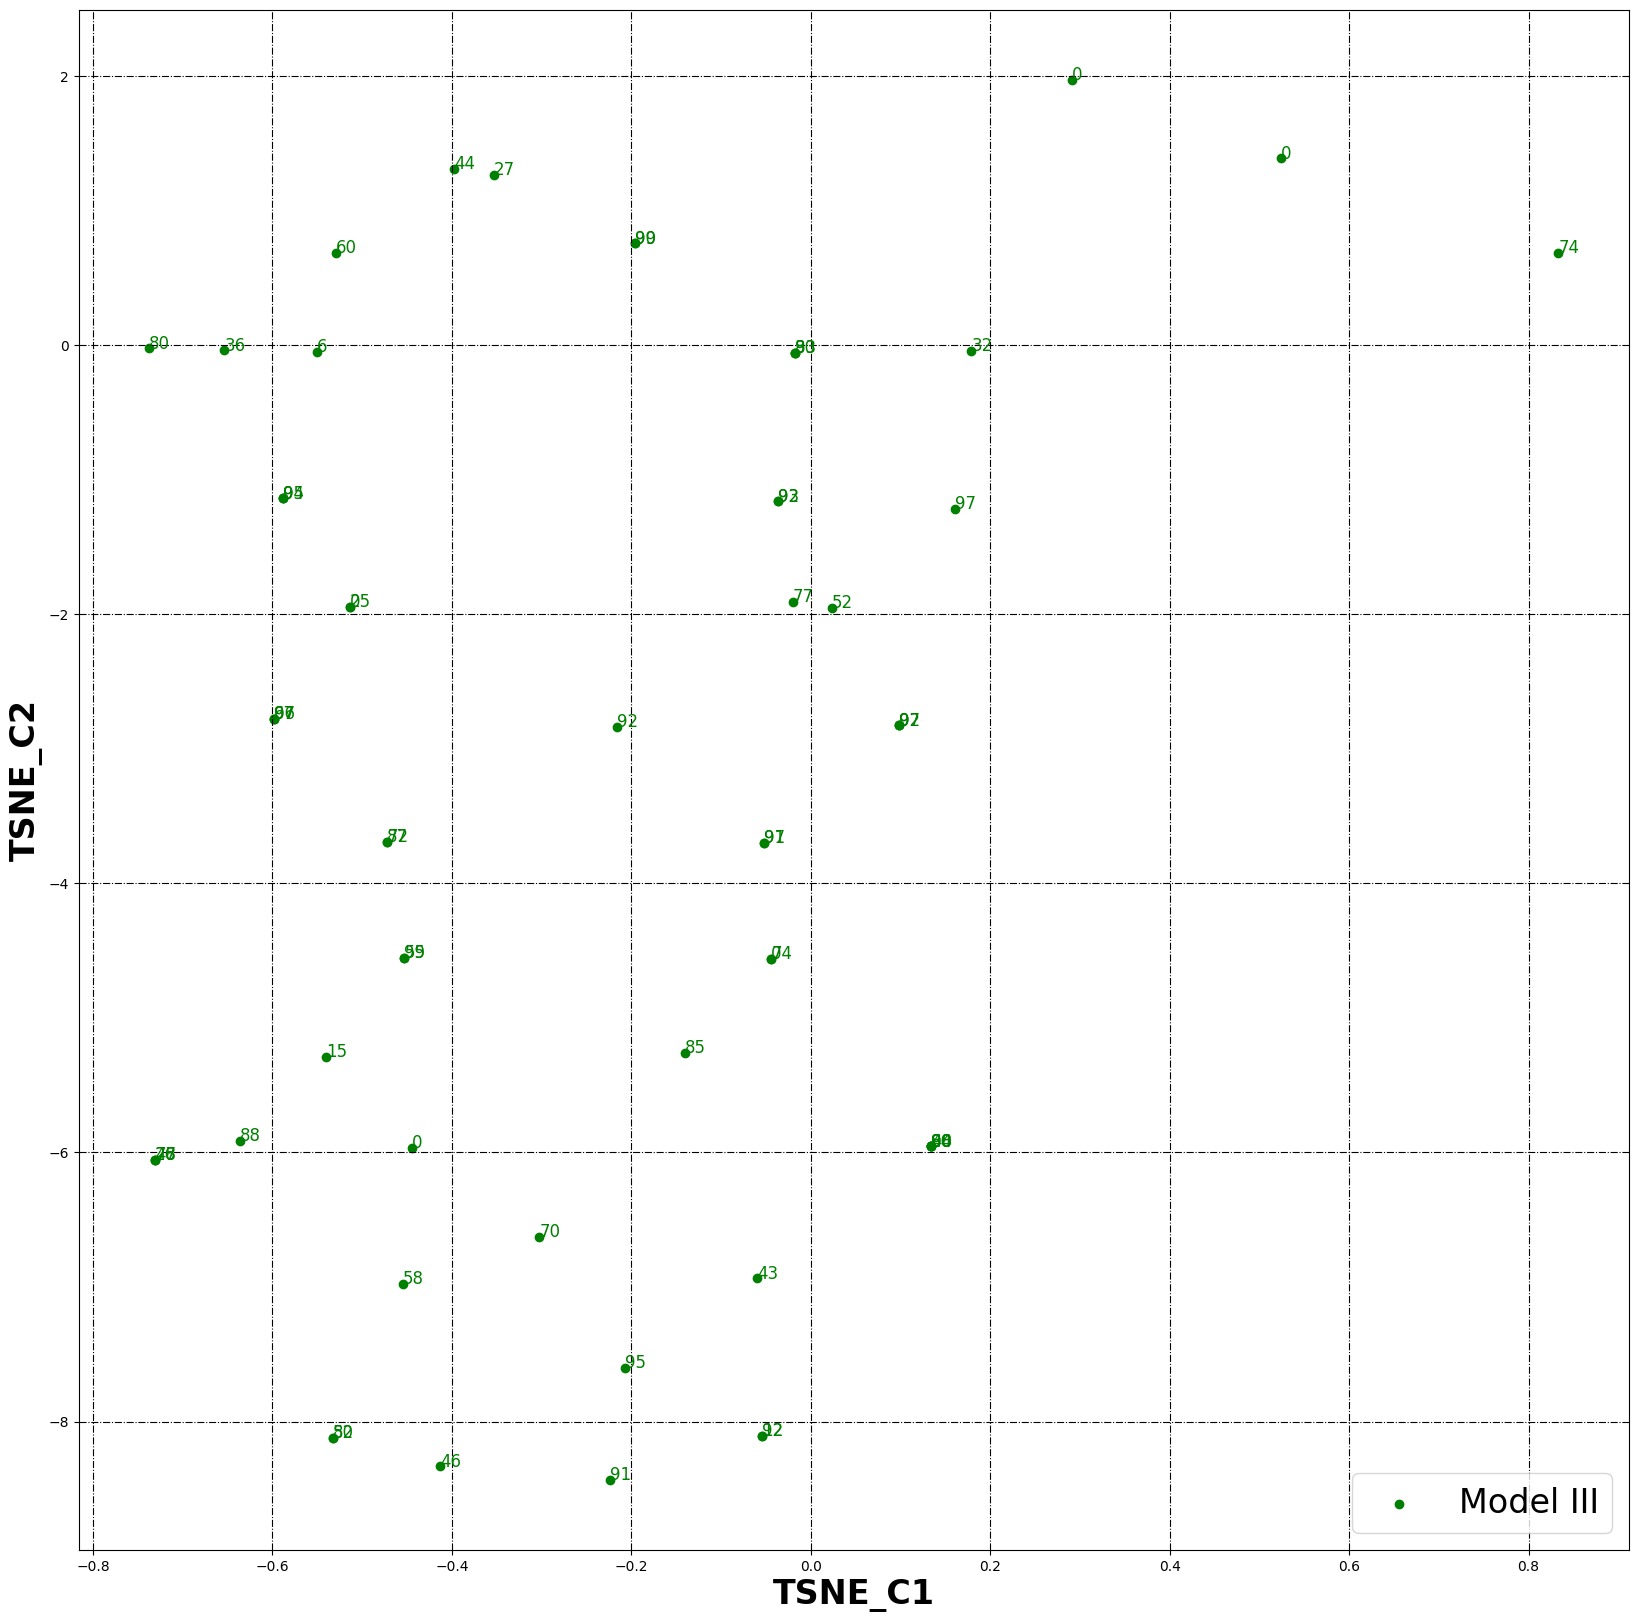

In [4]:

#First model
model_I = molecular_descriptors_df_I
model_I['Model'] = 'Model III'

#model_II = molecular_descriptors_df_II
#model_II['Model I / II'] = 'Model II'

# Concatenate DataFrames
whole_df = model_I# pd.concat([model_I, model_II], ignore_index=True)

simple_preprocessing = True #True
if simple_preprocessing:
    whole_df = whole_df.dropna(axis=1, how='any')
    print("Data size after first reduction (rows, columns): " + str(whole_df.shape))
        
whole_df_ = whole_df['ee'].copy()
whole_df__df = pd.DataFrame(data=whole_df_, columns=['ee'])
whole_df__ = whole_df.copy()

# t-SNE analysis
model = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=10000, init='pca')
tsne_whole_set = model.fit_transform(whole_df.iloc[:,:-2])

whole_df['TSNE_C1'] = tsne_whole_set.T[0]
whole_df['TSNE_C2'] = tsne_whole_set.T[1]

test = whole_df.copy()

        
x_model_I = whole_df.loc[whole_df['Model'] == 'Model III']
#x_model_II = whole_df.loc[whole_df['Model'] == 'Model II']

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

ax.scatter(x_model_I['TSNE_C1'], x_model_I['TSNE_C2'], c='g', marker="o", label='Model III') #, alpha=1
#ax.scatter(x_model_II['TSNE_C1'], x_model_II['TSNE_C2'], c='b', marker="s", label='Model II', alpha=0.5)#, alpha=0.1
#for i, txt in enumerate(x_model_II.index):
 #   ax.annotate(whole_df__df['ee'][i+41], (x_model_II['TSNE_C1'][i+41], x_model_II['TSNE_C2'][i+41]), fontsize=12, color='blue')
for i, txt in enumerate(x_model_I.index):
    ax.annotate(int(whole_df__df['ee'][i]), (x_model_I['TSNE_C1'][i], x_model_I['TSNE_C2'][i]), fontsize=12, color='green')
plt.legend(loc='lower right', fontsize=24)
plt.xlabel('TSNE_C1', fontweight='bold', fontsize=24)
plt.ylabel('TSNE_C2', fontweight='bold', fontsize=24)
plt.rc('grid', linestyle="-.", color='black')
plt.grid(True)
plt.savefig('t-SNE_analysis_'+'_MODELIII_'+'.svg', bbox_inches='tight')
        
# PCA analysis
pca = PCA(n_components=5, random_state=42) #n_components=20 in the case of activity_pred_app
pca_training_whole = pca.fit_transform(whole_df__.iloc[:,:-2])

list_pca = []
whole_data_II = pd.DataFrame(data=whole_df_, columns=['ee'])
for i in range(5):
    list_pca.append('PC'+str(i+1))
for pca_ in range(5):
    whole_data_II[list_pca[pca_]] = pca_training_whole.T[pca_]

        # t-SNE analysis
model = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=10000, init='pca')
tsne_whole_set = model.fit_transform(pca_training_whole)

tsne_whole_set_PCA = tsne_whole_set.copy()

whole_df['TSNE_C1'] = tsne_whole_set.T[0]
whole_df['TSNE_C2'] = tsne_whole_set.T[1]
x_model_I = whole_df.loc[whole_df['Model'] == 'Model III']
#x_model_II = whole_df.loc[whole_df['Model I / II'] == 'Model II']

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

ax.scatter(x_model_I['TSNE_C1'], x_model_I['TSNE_C2'], c='g', marker="o", label='Model III') #, alpha=1
#ax.scatter(x_model_II['TSNE_C1'], x_model_II['TSNE_C2'], c='b', marker="s", label='Model II', alpha=0.5)#, alpha=0.1
#for i, txt in enumerate(x_model_II.index):
 #   ax.annotate(whole_data_II['ee'][i+41], (x_model_II['TSNE_C1'][i+41], x_model_II['TSNE_C2'][i+41]), fontsize=12, color='blue')
for i, txt in enumerate(x_model_I.index): #may be txt instead of whole_data_II
    ax.annotate(int(whole_data_II['ee'][i]), (x_model_I['TSNE_C1'][i], x_model_I['TSNE_C2'][i]), fontsize=12, color='green')
plt.legend(loc='lower right', fontsize=24)
plt.xlabel('TSNE_C1', fontweight='bold', fontsize=24)
plt.ylabel('TSNE_C2', fontweight='bold', fontsize=24)
plt.rc('grid', linestyle="-.", color='black')
plt.grid(True)
plt.savefig('t-SNE_analysis_'+'_PCA_5_MODEL_III'+'.svg', bbox_inches='tight')

In [5]:
whole_df.iloc[:,:-4]

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1985,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2017,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2041
0,26.682927,5.770088,3.024390,6.178260,153.267812,105.649934,1.844467,5.906402,3.601607,7.350701,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,25.935484,5.706245,2.580645,4.751892,158.057747,102.435555,1.691055,5.821371,3.519689,7.342506,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23.860465,5.661247,2.744186,4.914154,157.443307,94.120542,1.670321,5.779477,3.312805,7.283060,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,24.764706,5.671282,2.529412,4.450254,158.718230,97.699954,1.650025,5.783676,3.334128,7.311622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,24.764706,5.671282,2.588235,4.567901,158.718230,97.699954,1.650025,5.783676,3.349651,7.311622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,24.700000,5.687590,2.700000,5.132716,156.835814,97.522176,1.703642,5.808375,3.397898,7.304853,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58,25.037037,5.728956,3.111111,6.024234,153.352717,99.029491,1.811354,5.865185,3.286509,7.305058,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59,24.392157,5.698306,2.901961,5.555071,154.914973,96.368631,1.753851,5.827696,3.268504,7.291208,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
60,30.727273,5.731982,3.000000,5.630752,153.662396,121.852796,1.930054,5.874975,3.343495,7.353626,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [6]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

df = whole_df.iloc[:,:-4]

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)

print(similarity_df)

# Calculate overall average similarity excluding self-similarity on the diagonal
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)

print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6    
0   1.000000  0.963094  0.998367  0.977046  0.977046  0.999839  0.999769  \
1   0.963094  1.000000  0.976882  0.998327  0.998327  0.958144  0.957094   
2   0.998367  0.976882  1.000000  0.987607  0.987607  0.997186  0.996909   
3   0.977046  0.998327  0.987607  1.000000  1.000000  0.973095  0.972248   
4   0.977046  0.998327  0.987607  1.000000  1.000000  0.973095  0.972248   
..       ...       ...       ...       ...       ...       ...       ...   
57  0.997129  0.980708  0.999818  0.990371  0.990371  0.995622  0.995275   
58  0.997255  0.940521  0.991398  0.958591  0.958591  0.998416  0.998615   
59  0.999171  0.951345  0.995215  0.967570  0.967570  0.999738  0.999815   
60  0.999949  0.960347  0.997742  0.974861  0.974861  0.999969  0.999935   
61  0.998127  0.944824  0.993004  0.962185  0.962185  0.999058  0.999210   

          7         8         9   ...        52        53        54        55   
0   0.

In [7]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.9405


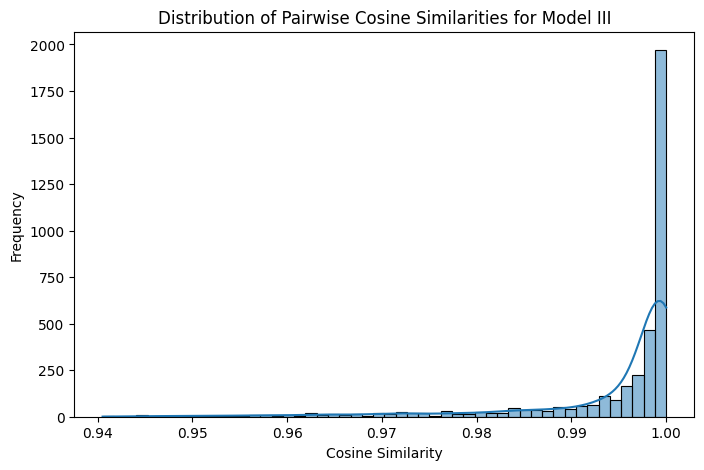

In [8]:
import seaborn as sns
# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Plot the distribution using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(sim_values, bins=50, kde=True)
plt.title('Distribution of Pairwise Cosine Similarities for Model III')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.savefig('cosine_similarities_III.svg', bbox_inches='tight')
plt.show()

In [9]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# Assuming whole_df is your original DataFrame
df = whole_df.iloc[:, :-3]  # Select all columns except last 3

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6    
0   1.000000  0.786852  0.937599  0.748616  0.744633  0.974637  0.936193  \
1   0.786852  1.000000  0.731932  0.978589  0.903083  0.816964  0.815317   
2   0.937599  0.731932  1.000000  0.696364  0.712969  0.928977  0.901351   
3   0.748616  0.978589  0.696364  1.000000  0.896153  0.777264  0.775697   
4   0.744633  0.903083  0.712969  0.896153  1.000000  0.775865  0.790253   
..       ...       ...       ...       ...       ...       ...       ...   
57  0.919540  0.821591  0.896478  0.781666  0.796503  0.937493  0.925273   
58  0.965769  0.823441  0.910874  0.783426  0.781686  0.970806  0.937811   
59  0.957895  0.817921  0.919556  0.778174  0.782132  0.967208  0.937713   
60  0.925122  0.827417  0.881924  0.787209  0.793024  0.938246  0.929875   
61  0.919304  0.855813  0.866272  0.823223  0.843670  0.929392  0.911999   

          7         8         9   ...        52        53        54        55   
0   0.

In [10]:
df_final

,C_FP_1,C_FP_2,C_FP_4,C_FP_14,C_FP_25,C_FP_31,C_FP_32,C_FP_33,C_FP_39,C_FP_45,...,C_FP_1985,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2017,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2041
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
60,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [11]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.6210
Maximal similarity between any two rows: 0.9897


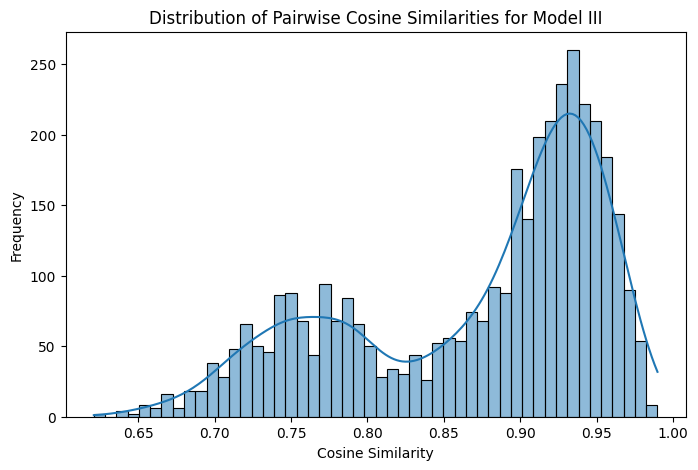

In [12]:
import seaborn as sns
# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Plot the distribution using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(sim_values, bins=50, kde=True)
plt.title('Distribution of Pairwise Cosine Similarities for Model III')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.savefig('cosine_similarities_III.svg', bbox_inches='tight')
plt.show()

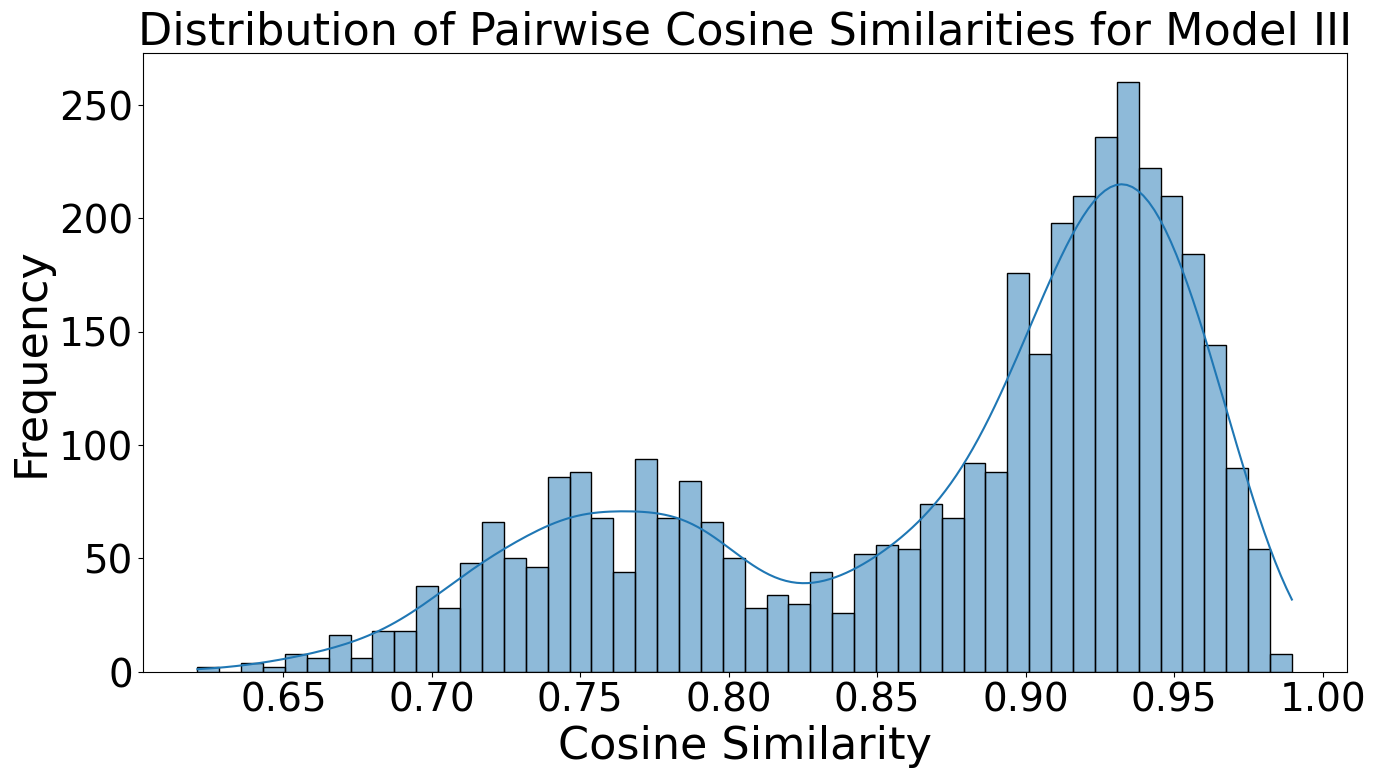

In [13]:
import seaborn as sns
# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Plot the distribution using seaborn
plt.figure(figsize=(14, 8))
sns.histplot(sim_values, bins=50, kde=True)
plt.title('Distribution of Pairwise Cosine Similarities for Model III', fontsize=32)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff
plt.savefig('cosine_similarities_III.svg', bbox_inches='tight')
plt.show()

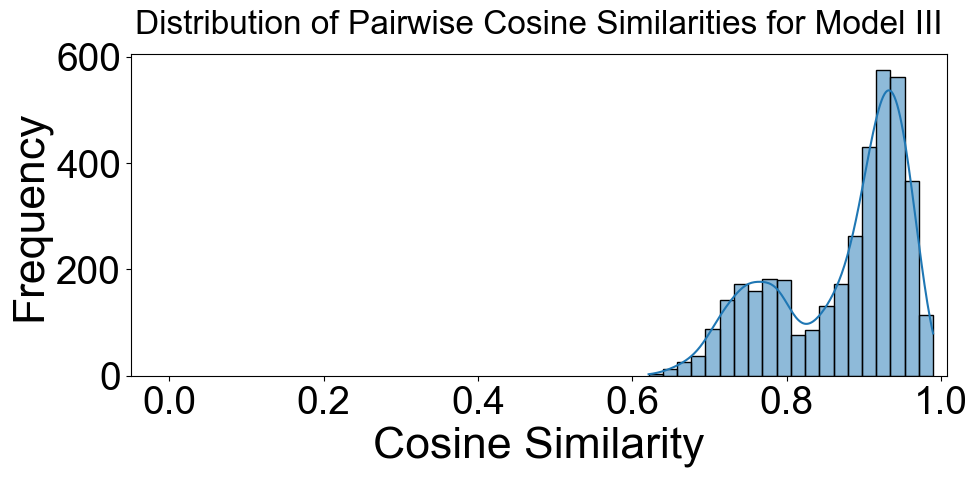

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=20, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for Model III', fontsize=24, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlim(-0.05)

plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_III.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()

In [15]:
whole_df.iloc[:,-2:]

,TSNE_C1,TSNE_C2
0,0.133889,-5.955124
1,-0.413019,-8.333566
2,-0.206993,-7.598053
3,-0.532378,-8.120192
4,-0.532378,-8.120192
...,...,...
57,-0.455016,-6.978559
58,-0.737370,-0.023944
59,-0.513368,-1.947535
60,-0.044043,-4.559484


In [16]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

df = whole_df.iloc[:,-2:]

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)

print(similarity_df)

# Calculate overall average similarity excluding self-similarity on the diagonal
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)

print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6    
0   1.000000  0.997409  0.998764  0.996135  0.996135  0.999923  0.999333  \
1   0.997409  1.000000  0.999752  0.999873  0.999873  0.996439  0.999371   
2   0.998764  0.999752  1.000000  0.999269  0.999269  0.998070  0.999913   
3   0.996135  0.999873  0.999269  1.000000  1.000000  0.994968  0.998679   
4   0.996135  0.999873  0.999269  1.000000  1.000000  0.994968  0.998679   
..       ...       ...       ...       ...       ...       ...       ...   
57  0.996167  0.999878  0.999283  1.000000  1.000000  0.995003  0.998697   
58  0.009982  0.081890  0.059662  0.097773  0.097773 -0.002437  0.046501   
59  0.960996  0.978401  0.973552  0.981573  0.981573  0.957487  0.970457   
60  0.999484  0.999206  0.999846  0.998443  0.998443  0.999007  0.999990   
61  0.877928  0.910097  0.900637  0.916590  0.916590  0.871915  0.894832   

          7         8         9   ...        52        53        54        55   
0   0.

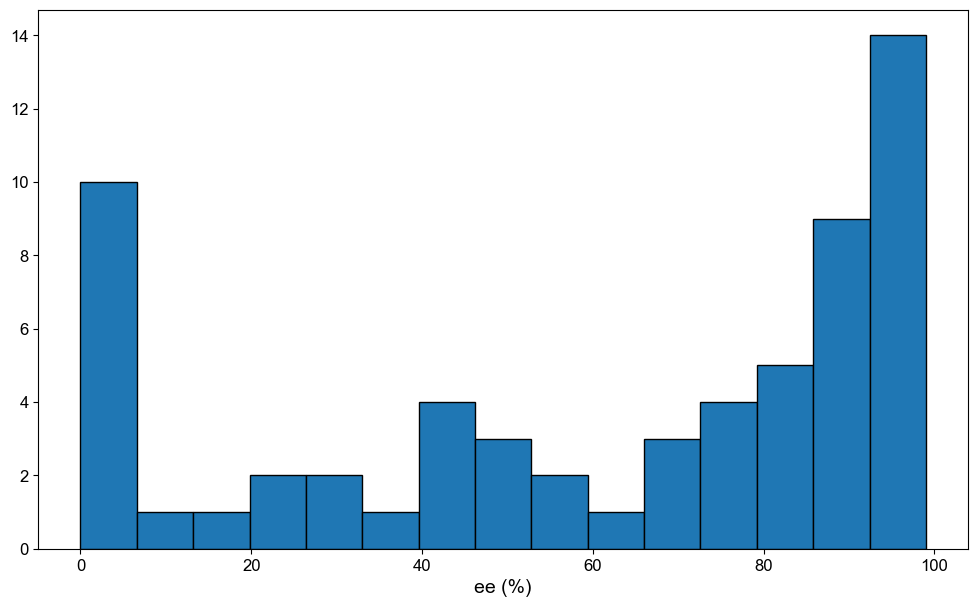

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame with column 'ee'
df = whole_df

plt.figure(figsize=(12, 7))  # Set a large figure size for better visibility
plt.hist(df['ee'], bins=15, edgecolor='black')  # Histogram of 'ee' column with bin edges outlined
#plt.title('Histogram of ee for model III', fontsize=18)
plt.xlabel('ee (%)', fontsize=14)
#plt.ylabel('Frequency', fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.6)  # Optional grid for readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('ee_distribution_III.svg', bbox_inches='tight')
plt.show()

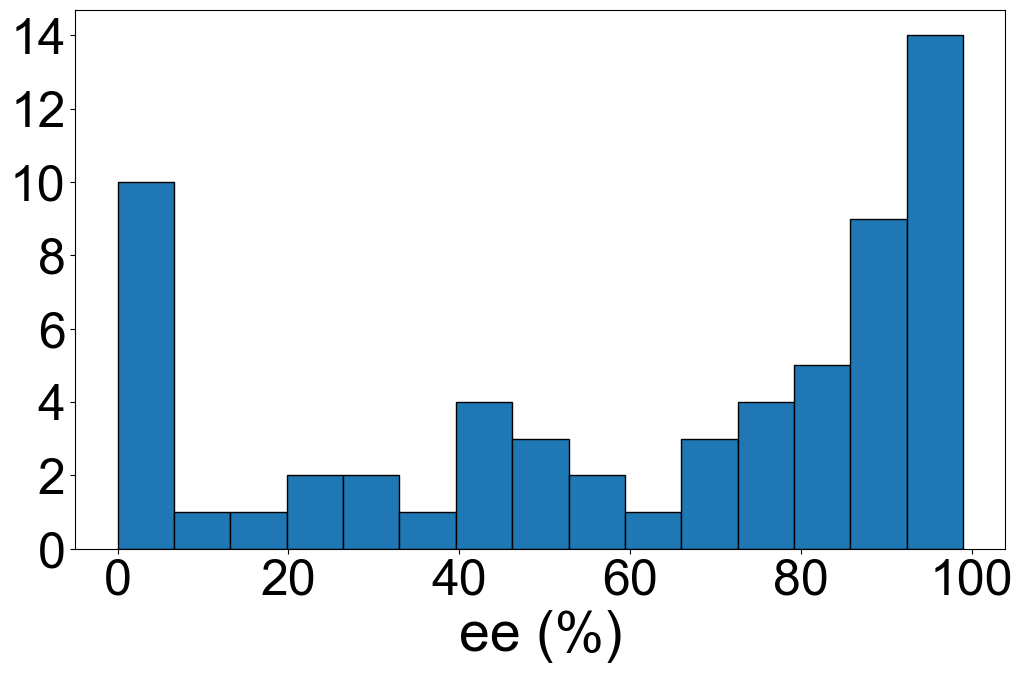

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame with column 'ee'
df = whole_df

plt.figure(figsize=(12, 7))  # Set a large figure size for better visibility
plt.hist(df['ee'], bins=15, edgecolor='black')  # Histogram of 'ee' column with bin edges outlined
#plt.title('Histogram of ee for model I', fontsize=18)
plt.xlabel('ee (%)', fontsize=40)
#plt.ylabel('Frequency', fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.6)  # Optional grid for readability
plt.xticks(fontsize=36)
plt.yticks(fontsize=36)
plt.savefig('ee_distribution_III.svg', bbox_inches='tight')
plt.show()